# Centralized Analysis for fl-tabular

This notebook is a centralized baseline for comparison with the Flower run. It uses the exact train, validation, and test datasets, drops `CRF01` from the analysis, trains one model end to end, prints progress during training, saves the final model, and evaluates the saved model on the held-out test split.

In [12]:
from pathlib import Path

import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from fltabular.task import CostRegressor, IGNORED_COLUMNS, _build_preprocessor, evaluator, get_input_dim

BATCH_SIZE = 16
NUM_EPOCHS = 800
LEARNING_RATE = 0.5
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def find_file_upwards(filename: str) -> Path:
    for directory in [Path.cwd(), *Path.cwd().parents]:
        candidate = directory / filename
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError(f'Could not find {filename} in {Path.cwd()} or any parent directory.')


train_path = find_file_upwards('train_db.pkl')
val_path = find_file_upwards('val_db.pkl')
test_path = find_file_upwards('test_db.pkl')

print(f'Using device: {DEVICE}')
print(f'Train data: {train_path}')
print(f'Val data:   {val_path}')
print(f'Test data:  {test_path}')

Using device: cpu
Train data: /home/ti-interns-1/Internship-2/flower/fl-tabular/train_db.pkl
Val data:   /home/ti-interns-1/Internship-2/flower/fl-tabular/val_db.pkl
Test data:  /home/ti-interns-1/Internship-2/flower/fl-tabular/test_db.pkl


In [13]:
def _prepare_frame(dataset: pd.DataFrame):
    dataset = dataset.dropna().reset_index(drop=True)
    target_column = 'COST_BL'
    feature_frame = dataset.drop(columns=[target_column], errors='ignore')
    feature_frame = feature_frame.drop(columns=list(IGNORED_COLUMNS), errors='ignore')
    y = pd.to_numeric(dataset[target_column], errors='coerce')
    valid_rows = y.notna()
    feature_frame = feature_frame.loc[valid_rows].reset_index(drop=True)
    y = y.loc[valid_rows].reset_index(drop=True)
    if feature_frame.empty:
        raise ValueError('A dataset split has no usable rows after target filtering.')
    return feature_frame, y


def load_exact_splits(batch_size: int = BATCH_SIZE):
    train_dataset = pd.read_pickle(train_path)
    val_dataset = pd.read_pickle(val_path)
    test_dataset = pd.read_pickle(test_path)

    x_train_frame, y_train = _prepare_frame(train_dataset)
    x_val_frame, y_val = _prepare_frame(val_dataset)
    x_test_frame, y_test = _prepare_frame(test_dataset)

    preprocessor = _build_preprocessor(x_train_frame)
    x_train = preprocessor.fit_transform(x_train_frame)
    x_val = preprocessor.transform(x_val_frame)
    x_test = preprocessor.transform(x_test_frame)

    train_loader = DataLoader(
        TensorDataset(
            torch.tensor(x_train, dtype=torch.float32),
            torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1),
        ),
        batch_size=batch_size,
        shuffle=True,
    )
    val_loader = DataLoader(
        TensorDataset(
            torch.tensor(x_val, dtype=torch.float32),
            torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1),
        ),
        batch_size=batch_size,
        shuffle=False,
    )
    test_loader = DataLoader(
        TensorDataset(
            torch.tensor(x_test, dtype=torch.float32),
            torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1),
        ),
        batch_size=batch_size,
        shuffle=False,
    )
    return train_loader, val_loader, test_loader, preprocessor


def train_centralized(model, train_loader, val_loader, 
                      num_epochs: int = NUM_EPOCHS, 
                      learning_rate: float = LEARNING_RATE):
    criterion = nn.L1Loss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    history = []
    model.train()
    for epoch in range(1, num_epochs + 1):
        running_loss = 0.0
        sample_count = 0
        for x_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            batch_size = y_batch.size(0)
            running_loss += loss.item() * batch_size
            sample_count += batch_size

        train_loss = running_loss / sample_count
        val_mae, val_mse, val_rmse, val_r2 = evaluator(model, val_loader)
        history.append((train_loss, val_mae, val_mse, val_rmse, val_r2))
        print(
            f'Epoch {epoch:03d}/{num_epochs} | '
            f'train_loss={train_loss:.4f} | '
            f'val_mae={val_mae:.4f} | '
            f'val_rmse={val_rmse:.4f} | '
            f'val_r2={val_r2:.4f}'
        )

    return history

In [14]:
train_loader, val_loader, test_loader, preprocessor = load_exact_splits(batch_size=BATCH_SIZE)

print(f'Train samples: {len(train_loader.dataset)}')
print(f'Validation samples: {len(val_loader.dataset)}')
print(f'Test samples: {len(test_loader.dataset)}')
print(f'Input dimension: {get_input_dim()}')

Train samples: 256
Validation samples: 64
Test samples: 81
Input dimension: 15


In [15]:
model = CostRegressor(get_input_dim()).to(DEVICE)
history = train_centralized(model, train_loader, val_loader, 
                            num_epochs=NUM_EPOCHS, 
                            learning_rate=LEARNING_RATE)

model_path = Path.cwd() / 'centralized_model.pt'
torch.save(model.state_dict(), model_path)

print('\nCentralized training complete')
print(f'Saved model to: {model_path}')
print(f'Final validation MAE:  {history[-1][1]:.4f}')
print(f'Final validation MSE:  {history[-1][2]:.4f}')
print(f'Final validation RMSE: {history[-1][3]:.4f}')
print(f'Final validation R2:   {history[-1][4]:.4f}')

Epoch 001/800 | train_loss=3205.8418 | val_mae=3465.4858 | val_rmse=5126.2164 | val_r2=-0.8417
Epoch 002/800 | train_loss=3161.2966 | val_mae=3417.0040 | val_rmse=5092.7308 | val_r2=-0.8177
Epoch 003/800 | train_loss=3116.2743 | val_mae=3369.1608 | val_rmse=5061.2372 | val_r2=-0.7953
Epoch 004/800 | train_loss=3071.6947 | val_mae=3320.8448 | val_rmse=5029.1963 | val_r2=-0.7726
Epoch 005/800 | train_loss=3026.5421 | val_mae=3272.9451 | val_rmse=4997.9489 | val_r2=-0.7506
Epoch 006/800 | train_loss=2982.2194 | val_mae=3224.0167 | val_rmse=4965.6234 | val_r2=-0.7281
Epoch 007/800 | train_loss=2936.7012 | val_mae=3176.3596 | val_rmse=4935.3613 | val_r2=-0.7071
Epoch 008/800 | train_loss=2892.0578 | val_mae=3128.0596 | val_rmse=4904.3370 | val_r2=-0.6857
Epoch 009/800 | train_loss=2847.2918 | val_mae=3079.7968 | val_rmse=4874.1785 | val_r2=-0.6650
Epoch 010/800 | train_loss=2802.4121 | val_mae=3031.2616 | val_rmse=4843.1980 | val_r2=-0.6439
Epoch 011/800 | train_loss=2757.4348 | val_mae=298

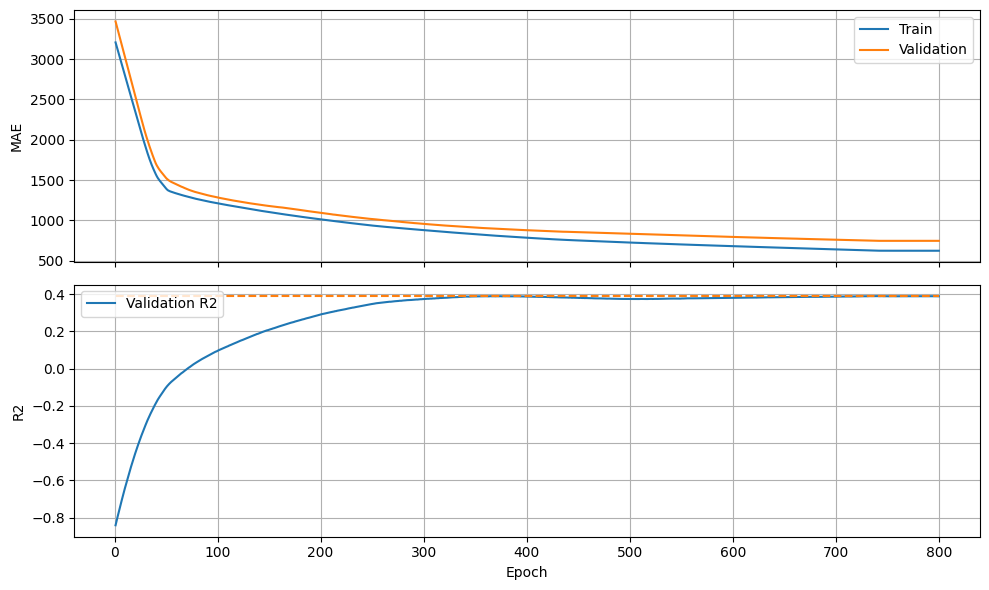

In [16]:
import numpy as np

import matplotlib.pyplot as plt

# extract metrics from history: (train_mae, val_mae, val_mse, val_rmse, val_r2)
train_mae = [h[0] for h in history]
val_mae = [h[1] for h in history]
val_r2 = [h[4] for h in history]
epochs = np.arange(1, len(history) + 1)

# compute train R2 for the final model (single value)
_, _, _, train_r2_final = evaluator(model, train_loader)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax1.plot(epochs, train_mae, label='Train')
ax1.plot(epochs, val_mae, label='Validation')
ax1.set_ylabel('MAE')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs, val_r2, label='Validation R2')
ax2.hlines(train_r2_final, epochs[0], epochs[-1], colors='C1', linestyles='--',
        #    label=f'Train R2 (final) = {train_r2_final:.3f}'
           )
ax2.set_xlabel('Epoch')
ax2.set_ylabel('R2')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [17]:
reloaded_model = CostRegressor(get_input_dim()).to(DEVICE)
reloaded_model.load_state_dict(torch.load(model_path, map_location=DEVICE))
test_mae, test_mse, test_rmse, test_r2 = evaluator(reloaded_model, test_loader)

print('Reloaded saved model evaluation on test split')
print(f'MAE:  {test_mae:.4f}')
print(f'MSE:  {test_mse:.4f}')
print(f'RMSE: {test_rmse:.4f}')
print(f'R2:   {test_r2:.4f}')

Reloaded saved model evaluation on test split
MAE:  558.7631
MSE:  2676881.4801
RMSE: 1636.1178
R2:   0.3649
